# 3 — Model: CNN Architecture

**Sprint 3** — Model Definition

This notebook defines the CNN model used to classify audio genres from mel spectrogram tensors.

- Re-instantiates the train/val/test DataLoaders from `2_transform.ipynb` using the same `load_split()` + `AudioDataset` pattern
- Defines `AudioCNN`, a 3-block convolutional network in PyTorch
- Verifies the forward pass produces the expected output shape `[batch, 10]`
- Instantiates the loss function (`CrossEntropyLoss`) and optimizer (`Adam`)

**Input shape:** `[batch, 1, 128, 1292]` — (batch, mono channel, mel bins, time frames)  
**Output shape:** `[batch, 10]` — one logit per genre class

## 1. Imports and Configuration

All configuration constants are kept identical to `2_transform.ipynb` so that the DataLoaders and mel spectrogram pipeline behave exactly as they did during preprocessing. `torch.nn` is added here for model definition.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("NUMBA_CACHE_DIR", str(Path.cwd() / ".numba-cache"))
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib-cache"))

# code/common.py lives alongside this notebook; ensure it's importable on a
# clean kernel restart regardless of exactly how Jupyter set cwd.
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from common import RANDOM_SEED, find_repo_root, load_split, AudioDataset, AudioCNN

BATCH_SIZE = 16

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Matplotlib is building the font cache; this may take a moment.


## 2. DataLoaders

The DataLoaders are re-instantiated here using the same `load_split()` + `AudioDataset` pattern from `2_transform.ipynb`. `load_split`, `pad_or_truncate`, `audio_to_mel_spectrogram`, `augment_waveform`, `augment_mel_spectrogram`, and `AudioDataset` are imported from `code/common.py` (shared with `2_transform.ipynb` and `4_predict.ipynb`) rather than redefined here, so all three notebooks always use identical preprocessing logic. Notebooks still do not share runtime state — the DB connection is re-established per notebook — but the logic itself is no longer duplicated.

In [2]:
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

repo_root = find_repo_root(Path.cwd())
load_dotenv(repo_root / ".env")

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD", "")
DB_HOST     = "localhost"
DB_PORT     = 5432
DB_NAME     = "audio_genre_classifier"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

try:
    with engine.connect() as con:
        db_name = con.execute(text("SELECT current_database()")).fetchone()[0]
    print(f"Connected to: {db_name}")
except Exception as e:
    print(f"Connection failed: {e}")

Connected to: audio_genre_classifier


In [3]:
metadata_df = pd.read_sql(
    sql=text("""
        SELECT ac.file_path, l.label_name AS label, ac.split
        FROM   audio_clips ac
        JOIN   labels l ON l.label_id = ac.label_id
        WHERE  ac.is_corrupted = FALSE
          AND  ac.is_duplicate = FALSE
        ORDER  BY ac.file_path
    """),
    con=engine,
)

labels = sorted(metadata_df["label"].unique())
label_to_idx = {label: idx for idx, label in enumerate(labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

train_df = load_split("train", engine)
val_df   = load_split("val",   engine)
test_df  = load_split("test",  engine)

train_dataset = AudioDataset(train_df, label_to_idx=label_to_idx, augment=True)
val_dataset   = AudioDataset(val_df,   label_to_idx=label_to_idx, augment=False)
test_dataset  = AudioDataset(test_df,  label_to_idx=label_to_idx, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train examples : {len(train_dataset)}")
print(f"Val examples   : {len(val_dataset)}")
print(f"Test examples  : {len(test_dataset)}")
print(f"Label mapping  : {label_to_idx}")

Train examples : 699
Val examples   : 150
Test examples  : 150
Label mapping  : {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


## 3. CNN Architecture

`AudioCNN` is imported from `code/common.py` (shared with `4_predict.ipynb`, which reloads the exact same architecture to evaluate the saved checkpoint). It treats each mel spectrogram as a single-channel image and learns hierarchical frequency-time patterns through three convolutional blocks.

**Block structure — Conv2d → BatchNorm2d → ReLU → MaxPool2d:**

| Block | In channels | Out channels | Spatial size after pool |
|-------|------------|--------------|-------------------------|
| 1     | 1          | 32           | [32, 64, 646]           |
| 2     | 32         | 64           | [64, 32, 323]           |
| 3     | 64         | 128          | [128, 16, 161]          |

**Architecture decisions:**

- **3×3 convolutions with `padding=1`** — preserves spatial dimensions before pooling so each block halves H and W cleanly via `MaxPool2d(2, 2)`. 3×3 is the standard kernel for capturing local frequency-time patterns.
- **Doubling channels per block (32→64→128)** — compensates for the spatial information lost at each pooling step so the total feature volume stays roughly constant. No single layer becomes a bottleneck.
- **BatchNorm2d after every Conv2d** — normalizes activations before the non-linearity, which stabilizes gradients and allows a higher learning rate without careful initialization.
- **`AdaptiveAvgPool2d((4, 4))` before the classifier** — reduces `[128, 16, 161]` to a fixed `[128, 4, 4]` (2,048 values). Flattening directly after block 3 would produce a 329,728-element vector and a ~84M-parameter FC layer on a 700-example training set. The adaptive pool keeps the FC layer at a manageable 2,048→256 (~500K params) and adds mild translation invariance.
- **Dropout(0.5)** — applied after the hidden FC layer, the widest point of the classifier head and where overfitting risk is highest on a small dataset.
- **10 output units, no final activation** — `CrossEntropyLoss` applies log-softmax internally; adding a softmax here would double-apply it.

## 4. Device, Model Instantiation, and Parameter Count

The model is moved to GPU if one is available; otherwise it runs on CPU. Printing the total parameter count confirms the model loaded correctly and gives a quick sanity check on architecture size before any training.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = AudioCNN(num_classes=10).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Device: cpu
Total parameters     : 620,234
Trainable parameters : 620,234


## 5. Loss Function and Optimizer

**`CrossEntropyLoss`** — the standard loss for multi-class classification. It combines `LogSoftmax` and `NLLLoss` internally, so the output layer produces raw logits (no activation needed). GTZAN is balanced across 10 classes so no class weights are applied.

**`Adam` with `lr=1e-3`** — Adam adapts the learning rate per parameter using first and second moment estimates, making it less sensitive to the initial learning rate than SGD. `1e-3` is the conventional Adam starting point for small-to-medium CNN tasks and pairs well with BatchNorm.

In [5]:
LEARNING_RATE = 1e-3
EPOCHS = 10
PATIENCE = 3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Loss      : {criterion}")
print(f"Optimizer : {optimizer.__class__.__name__}, lr={optimizer.param_groups[0]['lr']}")

Loss      : CrossEntropyLoss()
Optimizer : Adam, lr=0.001


## 6. Forward Pass Verification

Runs one batch through the model to confirm the output shape is `[batch, 10]` and that no errors occur. This catches shape mismatches or device mismatches before a full training run that could take hours.

In [6]:
model.eval()
with torch.no_grad():
    sample_features, sample_labels = next(iter(train_loader))
    sample_features = sample_features.to(device)
    sample_labels   = sample_labels.to(device)

    output = model(sample_features)

print(f"Input shape  : {sample_features.shape}")
print(f"Output shape : {output.shape}")
print(f"Expected     : [{sample_features.shape[0]}, 10]")
assert output.shape == (sample_features.shape[0], 10), "Output shape mismatch!"
print("Forward pass OK")

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input shape  : torch.Size([16, 1, 128, 1292])
Output shape : torch.Size([16, 10])
Expected     : [16, 10]
Forward pass OK


## 7. Training and Validation

The model trains for up to **10 epochs**, with early stopping after **3 consecutive epochs** without improved validation accuracy; best-checkpoint saving preserves the strongest epoch. The **batch size of 16** comes from the DataLoader configuration and balances memory use with reasonably stable gradient updates.

For every training batch, the loop performs a forward pass, calculates cross-entropy loss, clears old gradients, backpropagates the new gradients, and updates the weights with Adam. Validation runs after each epoch inside `torch.no_grad()` so it does not build gradient graphs or update model parameters. Training loss, validation loss, and validation accuracy are retained for plotting.

In [7]:
checkpoint_path = repo_root / "models" / "best_model.pth"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

if len(train_loader) == 0 or len(val_loader) == 0:
    raise ValueError("Training and validation DataLoaders must not be empty.")

train_loss = []
val_loss = []
val_accuracy = []
best_val_accuracy = -1.0
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    train_examples = 0

    for features, targets in train_loader:
        features = features.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        batch_size = targets.size(0)
        running_train_loss += loss.item() * batch_size
        train_examples += batch_size

    epoch_train_loss = running_train_loss / train_examples
    train_loss.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    correct_predictions = 0
    val_examples = 0

    with torch.no_grad():
        for features, targets in val_loader:
            features = features.to(device)
            targets = targets.to(device)

            logits = model(features)
            loss = criterion(logits, targets)
            predictions = logits.argmax(dim=1)

            batch_size = targets.size(0)
            running_val_loss += loss.item() * batch_size
            correct_predictions += (predictions == targets).sum().item()
            val_examples += batch_size

    epoch_val_loss = running_val_loss / val_examples
    epoch_val_accuracy = correct_predictions / val_examples
    val_loss.append(epoch_val_loss)
    val_accuracy.append(epoch_val_accuracy)

    if epoch_val_accuracy > best_val_accuracy:
        best_val_accuracy = epoch_val_accuracy
        epochs_without_improvement = 0
        torch.save(model.state_dict(), checkpoint_path)
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"train_loss: {epoch_train_loss:.4f} | "
        f"val_loss: {epoch_val_loss:.4f} | "
        f"val_accuracy: {epoch_val_accuracy:.2%}"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping after {epoch + 1} epochs.")
        break

print(f"Best validation accuracy: {best_val_accuracy:.2%}")
print(f"Best model saved to: {checkpoint_path}")

Epoch 01/10 | train_loss: 2.1230 | val_loss: 1.7243 | val_accuracy: 34.67%


Epoch 02/10 | train_loss: 1.6975 | val_loss: 1.9286 | val_accuracy: 30.00%


Epoch 03/10 | train_loss: 1.5949 | val_loss: 1.9453 | val_accuracy: 26.67%


Epoch 04/10 | train_loss: 1.4959 | val_loss: 1.9869 | val_accuracy: 32.00%
Early stopping after 4 epochs.
Best validation accuracy: 34.67%
Best model saved to: /Users/ac/Projects/tkh_projects/audio-genre-classifier/models/best_model.pth


## 8. Training Curves

The left panel compares training and validation cross-entropy loss. The right panel shows validation accuracy. The combined figure is saved to `docs/images/training_curves.png`.

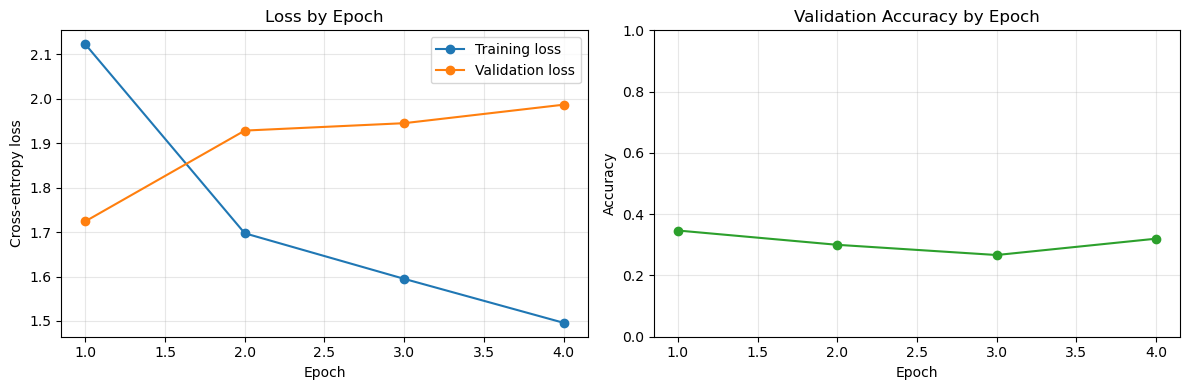

Training curves saved to: /Users/ac/Projects/tkh_projects/audio-genre-classifier/docs/images/training_curves.png


In [8]:
curves_path = repo_root / "docs" / "images" / "training_curves.png"
curves_path.parent.mkdir(parents=True, exist_ok=True)
epochs = range(1, len(train_loss) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss, marker="o", label="Training loss")
axes[0].plot(epochs, val_loss, marker="o", label="Validation loss")
axes[0].set(title="Loss by Epoch", xlabel="Epoch", ylabel="Cross-entropy loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, val_accuracy, marker="o", color="tab:green")
axes[1].set(title="Validation Accuracy by Epoch", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show(block=False)
plt.close(fig)
print(f"Training curves saved to: {curves_path}")

## 9. Interpreting the Curves

- **Convergence:** training and validation loss flatten while validation accuracy stops making meaningful gains. The saved checkpoint preserves the epoch with the highest validation accuracy even if training continues afterward.
- **Overfitting:** training loss keeps falling while validation loss rises or validation accuracy stalls. A widening loss gap suggests that the model is memorizing training examples rather than improving on unseen audio.
- **Underfitting:** both losses remain high and validation accuracy stays low or improves very slowly. This can indicate insufficient model capacity, inadequate training time, or hyperparameters that need adjustment.

--------------

## Summary

This notebook defines and trains the CNN model for GTZAN genre classification.

**What was done:**
- Re-instantiated train/val/test DataLoaders using the same `load_split()` + `AudioDataset` pipeline from `2_transform.ipynb`
- Defined `AudioCNN`: 3 convolutional blocks (Conv2d → BatchNorm2d → ReLU → MaxPool2d), adaptive average pooling, and a fully-connected classifier head with Dropout
- Confirmed forward pass produces `[batch, 10]` output
- Instantiated `CrossEntropyLoss` and `Adam(lr=1e-3)`
- Trained and validated for up to 10 epochs with early stopping while tracking loss and validation accuracy
- Saved the best model weights and the training-curve figure

**Architecture summary:**

| Component | Details |
|---|---|
| Input | `[batch, 1, 128, 1292]` |
| Block 1 | Conv2d(1→32, 3×3) → BN → ReLU → MaxPool |
| Block 2 | Conv2d(32→64, 3×3) → BN → ReLU → MaxPool |
| Block 3 | Conv2d(64→128, 3×3) → BN → ReLU → MaxPool |
| Pool | AdaptiveAvgPool2d → `[128, 4, 4]` |
| Classifier | Flatten → Linear(2048, 256) → ReLU → Dropout(0.5) → Linear(256, 10) |
| Output | `[batch, 10]` logits |
| Loss | CrossEntropyLoss |
| Optimizer | Adam, lr=1e-3 |

## Handoff to Ticket #54 — Evaluation

Ticket #54 should build on the trained model and test split prepared here. Evaluation is intentionally **not implemented in this notebook section**.

**Available for evaluation:**

- `AudioCNN` — the exact architecture required to reload the saved weights.
- `test_loader` — the held-out test split with augmentation disabled.
- `label_to_idx` and `idx_to_label` — the shared mapping between genre names and class indices.
- `device` — the device selected for model execution.
- `models/best_model.pth` — the state dictionary from the epoch with the highest validation accuracy.
- `docs/images/training_curves.png` — the loss and validation-accuracy curves produced after training.

**Before starting Ticket #54:** run this notebook through the training and plotting cells so the checkpoint and curves exist locally. The `models/` directory is intentionally ignored by Git, so checkpoints are generated locally rather than committed. Then instantiate the same `AudioCNN`, load `best_model.pth` with the appropriate device mapping, switch to evaluation mode, and evaluate `test_loader` under `torch.no_grad()`.

Ticket #54 owns test accuracy, per-genre precision/recall/F1, the confusion matrix saved to `docs/images/confusion_matrix.png`, and the final evidence-based interpretation of performance and training curves.

**Decision carried into Ticket #54:** `4_predict.ipynb` imports `AudioDataset` and `AudioCNN` from `code/common.py` (the same shared module this notebook uses) rather than repeating a minimal evaluation-only definition, while keeping the database split query, label mapping, checkpoint path, and saved plot locations aligned with this handoff. The checkpoint remains a raw state dictionary, so evaluation reloads the exact architecture via `common.AudioCNN` and treats `docs/images/training_curves.png` as the durable training-curve artifact.
